In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
sensors_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.000004,0.984199,0.094463,0.000373,0.999849


In [2]:
X = rf_preprocessor.group_and_pad(sensors_df, group_col="Experiment_ID")[:,:,1:]
Y = rf_preprocessor.group_and_pad(target_df, group_col="Experiment_ID")[:,:-1,2:]
X.shape

(100, 1743, 15)

In [57]:
import pandas as pd
import numpy as np

# Assume your DataFrame is called df and 'Time_[s]' is the index
df = sensors_df.reset_index()  # make 'Time_[s]' a column if it's the index

def resample_experiment(group, n=46):
    # Create 46 equally spaced timestamps between min and max time
    new_times = np.linspace(group['Time_[s]'].min(), group['Time_[s]'].max(), n)
    
    # Interpolate all columns (except 'Experiment_ID') to the new timestamps
    interpolated = pd.DataFrame({'Time_[s]': new_times})
    for col in group.columns:
        if col != 'Time_[s]' and col != 'Experiment_ID':
            interpolated[col] = np.interp(new_times, group['Time_[s]'], group[col])
    
    # Keep the Experiment_ID
    interpolated['Experiment_ID'] = group['Experiment_ID'].iloc[0]
    
    return interpolated
#
# Apply to each Experiment_ID
df_resampled = df.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=46))
df_resampled = df_resampled.reset_index(drop=True)


/tmp/ipykernel_77247/260013275.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resampled = df.groupby('Experiment_ID').apply(lambda g: resample_experiment(g, n=46))


In [3]:
import pandas as pd
import numpy as np

def normalize_experiment(group, n=46):
    if len(group) > n:
        # Just take the first 46 rows
        return group.iloc[:n].copy()
    else:
        # Already 46 rows
        return group.copy()

# Apply to each experiment
df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)
df_normalized = df_normalized.reset_index(drop=True)


/tmp/ipykernel_103928/900614170.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_normalized = target_df.groupby('Experiment_ID', group_keys=False).apply(normalize_experiment, n=47)


In [4]:
count= 2
X = X#rf_preprocessor.group_and_pad(df_resampled, group_col="Experiment_ID")[:,:,count:]
Y = rf_preprocessor.group_and_pad(df_normalized, group_col="Experiment_ID")[:,:-1,1:]

In [5]:
X.shape, Y.shape

((100, 1743, 15), (100, 46, 4))

# LIFT

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ----------------------------------
# 1️⃣ Example: Assume you already have X and Y
# ----------------------------------
# X: (100, 1743, 15)
# Y: (100, 46, 4)
# Replace these with your actual data loading
# X, Y = your_data_loading_function()

# ----------------------------------
# 2️⃣ Create LSTM windows from long sequences
# ----------------------------------
def create_lstm_windows(X, Y, window_size=100, horizon=1):
    """
    Creates sliding windows for LSTM training.
    X: (num_samples, seq_len, num_features)
    Y: (num_samples, target_seq_len, num_outputs)
    Returns:
        Xw: (num_windows, window_size, num_features)
        Yw: (num_windows, num_outputs)
    """
    X_windows, Y_windows = [], []
    
    for i in range(len(X)):  # iterate through samples
        x_seq = X[i]
        y_seq = Y[i]
        seq_len = len(x_seq)
        for j in range(seq_len - window_size - horizon + 1):
            X_windows.append(x_seq[j:j+window_size])
            # pick one future point (here last available if shorter)
            Y_windows.append(y_seq[min(j+window_size, len(y_seq)-1)])
    
    X_windows = np.array(X_windows)
    Y_windows = np.array(Y_windows)
    return X_windows, Y_windows


# ----------------------------------
# 3️⃣ Create tensors
# ----------------------------------
window_size = 100
Xw, Yw = create_lstm_windows(X, Y, window_size)

print(f"Windowed X shape: {Xw.shape}")
print(f"Windowed Y shape: {Yw.shape}")

x_tensor = torch.tensor(Xw, dtype=torch.float32)
y_tensor = torch.tensor(Yw, dtype=torch.float32)


# ----------------------------------
# 4️⃣ Define the Complex LSTM model
# ----------------------------------
class ComplexLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim*2)
        self.fc1 = nn.Linear(hidden_dim*2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq_len, hidden_dim*2)
        out = out[:, -1, :]            # last time step
        out = self.layer_norm(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out


# ----------------------------------
# 5️⃣ Model, loss, optimizer, scheduler
# ----------------------------------
model = ComplexLSTM(
    input_dim=Xw.shape[-1],
    hidden_dim=64,
    output_dim=Yw.shape[-1],
    num_layers=2
)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)


# ----------------------------------
# 6️⃣ Training loop
# ----------------------------------
epochs = 50
batch_size = 16

for epoch in range(epochs):
    permutation = torch.randperm(x_tensor.size(0))
    epoch_loss = 0.0
    
    for i in range(0, x_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = x_tensor[indices]
        batch_y = y_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (x_tensor.size(0)//batch_size)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

print("✅ Training complete!")


Windowed X shape: (164300, 100, 15)
Windowed Y shape: (164300, 4)


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.float32)

feature_names = list(sensors_df.columns)[count:]

# --------------------------
# More Complex LSTM Model
# --------------------------
class ComplexLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers, 
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim*2)
        self.fc1 = nn.Linear(hidden_dim*2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)                # (batch, seq_len, hidden_dim*2)
        out = self.layer_norm(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = ComplexLSTM(input_dim=X.shape[-1], hidden_dim=512, output_dim=Y.shape[-1], num_layers=6)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)

# --------------------------
# Training loop
# --------------------------
epochs = 50
batch_size = 16

for epoch in range(epochs):
    permutation = torch.randperm(x_tensor.size(0))
    epoch_loss = 0
    
    for i in range(0, x_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_tensor[indices], y_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / (x_tensor.size(0)//batch_size)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

print("Training complete!")

In [7]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import GuidedBackprop, DeepLift, IntegratedGradients, Saliency, InputXGradient

# --------------------------
# Compute attributions
# --------------------------
def compute_attr(sample_input, output_feature, time_step, method_cls):
    class WrappedModel(nn.Module):
        def __init__(self, base_model, time_step, output_feature):
            super().__init__()
            self.base_model = base_model
            self.time_step = time_step
            self.output_feature = output_feature

        def forward(self, x):
            out = self.base_model(x)
            return out[:, self.time_step, self.output_feature]

    wrapped_model = WrappedModel(model, time_step, output_feature)
    method = method_cls(wrapped_model)
    attr = method.attribute(sample_input)
    return attr.detach().numpy().reshape(sample_input.shape[1], sample_input.shape[2])  # (features, time)

# --------------------------
# Widgets
# --------------------------
sample_selector = widgets.IntSlider(
    value=0, min=0, max=x_tensor.shape[0]-1, step=1, description='Sample'
)

feature_selector = widgets.IntSlider(
    value=0, min=0, max=y_tensor.shape[2]-1, step=1, description='Output Feature'
)

time_selector = widgets.IntSlider(
    value=0, min=0, max=x_tensor.shape[1]-1, step=1, description='Time Step'
)
methods = {
    "GuidedBackprop": GuidedBackprop,
    "DeepLift": DeepLift,
    "IntegratedGradients": IntegratedGradients,
    "Saliency": Saliency,
    "InputXGradient": InputXGradient
}
method_selector = widgets.Dropdown(
    options=list(methods.keys()),
    value=list(methods.keys())[0],
    description='Method'
)

out = widgets.Output()

# --------------------------
# Update plot function
# --------------------------
# --------------------------
# Update plot function with internal legends
# --------------------------
def update_plot(change):
    sample_idx = sample_selector.value
    output_feature = feature_selector.value
    time_step = time_selector.value
    method_name = method_selector.value

    sample_input = x_tensor[sample_idx:sample_idx+1]  # (1, seq_len, features)
    attr_np = compute_attr(sample_input, output_feature, time_step, methods[method_name])

    target_value = model(sample_input)[0, time_step, output_feature].item()  # scalar
    sensor_values = sample_input[0].detach().numpy()  # (time, features)

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

        # Attribution map
        im = axes[0].imshow(attr_np.T, cmap='seismic', aspect='auto')
        axes[0].set_title(f"Attribution Map: {method_name}")
        axes[0].set_ylabel("Feature")
        axes[0].set_yticks(np.arange(len(feature_names)))
        axes[0].set_yticklabels(feature_names, fontsize=8)
        cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

        # Target value over time
        axes[1].plot(model(sample_input).detach().numpy()[0, :, output_feature], label='Model Output')
        axes[1].plot(Y[sample_idx, :, output_feature], label='Model Output')
        axes[1].scatter(time_step, target_value, color='red', label='Selected Time Step')
        axes[1].set_ylabel("Target Value")
        axes[1].set_title(f"Model Output (Feature {output_feature})")
        axes[1].legend(loc='upper left', fontsize=8)

        # Sensor input values
        for i, fname in enumerate(feature_names):
            axes[2].plot(sensor_values[:, i], label=fname)
        axes[2].set_xlabel("Time Step")
        axes[2].set_ylabel("Sensor Value")
        axes[2].set_title("Input Sensor Values")
        #axes[2].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=6, ncol=2)  # inside figure

        plt.tight_layout()
        plt.show()


# Link all widgets to the update function
for w in [sample_selector, feature_selector, time_selector, method_selector]:
    w.observe(update_plot, names='value')

# Display widgets
display(widgets.VBox([sample_selector, feature_selector, time_selector, method_selector, out]))

# Initial plot
update_plot(None)


IndexError: tuple index out of range

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from captum.attr import GuidedBackprop, DeepLift, IntegratedGradients, Saliency, InputXGradient

# --------------------------
# Attribution computation
# --------------------------
def compute_attr(sample_input, output_feature, method_cls):
    """
    Computes feature attributions for a specific output feature.
    Works with models that output (batch, output_dim).
    """
    class WrappedModel(nn.Module):
        def __init__(self, base_model, output_feature):
            super().__init__()
            self.base_model = base_model
            self.output_feature = output_feature

        def forward(self, x):
            out = self.base_model(x)
            return out[:, self.output_feature]  # (batch,)

    wrapped_model = WrappedModel(model, output_feature)
    method = method_cls(wrapped_model)
    attr = method.attribute(sample_input)
    # reshape (1, seq_len, features) -> (seq_len, features)
    return attr.detach().cpu().numpy().reshape(sample_input.shape[1], sample_input.shape[2])

# --------------------------
# Widgets
# --------------------------
sample_selector = widgets.IntSlider(
    value=0, min=0, max=x_tensor.shape[0] - 1, step=1, description='Sample'
)

feature_selector = widgets.IntSlider(
    value=0, min=0, max=y_tensor.shape[1] - 1, step=1, description='Output Feature'
)

method_selector = widgets.Dropdown(
    options=["GuidedBackprop", "DeepLift", "IntegratedGradients", "Saliency", "InputXGradient"],
    value="IntegratedGradients",
    description='Method'
)

methods = {
    "GuidedBackprop": GuidedBackprop,
    "DeepLift": DeepLift,
    "IntegratedGradients": IntegratedGradients,
    "Saliency": Saliency,
    "InputXGradient": InputXGradient
}

out = widgets.Output()

# --------------------------
# Update plot function
# --------------------------
def update_plot(change):
    sample_idx = sample_selector.value
    output_feature = feature_selector.value
    method_name = method_selector.value

    sample_input = x_tensor[sample_idx:sample_idx + 1]  # (1, seq_len, features)
    attr_np = compute_attr(sample_input, output_feature, methods[method_name])  # (seq_len, features)

    # Predictions
    pred = model(sample_input).detach().cpu().numpy()[0, output_feature]
    true_val = y_tensor[sample_idx, output_feature].item() if len(y_tensor.shape) == 2 else None

    sensor_values = sample_input[0].detach().cpu().numpy()  # (seq_len, features)

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        # Attribution heatmap
        im = axes[0].imshow(attr_np.T, cmap='seismic', aspect='auto')
        axes[0].set_title(f"Attribution Map: {method_name} (Output Feature {output_feature})")
        axes[0].set_ylabel("Input Feature")
        if 'feature_names' in globals():
            axes[0].set_yticks(np.arange(len(feature_names)))
            axes[0].set_yticklabels(feature_names, fontsize=8)
        cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

        # Input feature time-series
        for i in range(sensor_values.shape[1]):
            label = feature_names[i] if 'feature_names' in globals() else f"Feature {i}"
            axes[1].plot(sensor_values[:, i], label=label)
        axes[1].set_title("Input Sensor Values")
        axes[1].set_xlabel("Time Step")
        axes[1].set_ylabel("Sensor Value")
        axes[1].legend(fontsize=7, loc='upper right')

        plt.tight_layout()
        plt.show()

        print(f"Predicted Value (Output {output_feature}): {pred:.4f}")
        if true_val is not None:
            print(f"True Value: {true_val:.4f}")

# --------------------------
# Link widgets and display
# --------------------------
for w in [sample_selector, feature_selector, method_selector]:
    w.observe(update_plot, names='value')

display(widgets.VBox([sample_selector, feature_selector, method_selector, out]))
update_plot(None)


/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/deep_lift.py:810: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


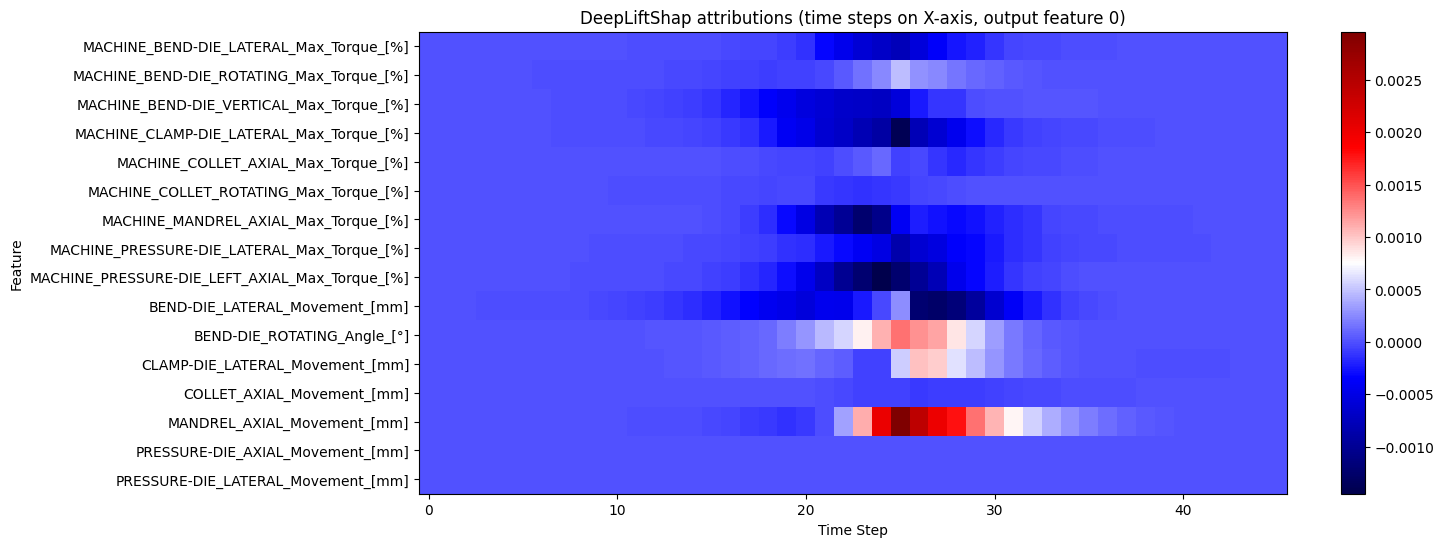

In [10]:
from captum.attr import DeepLiftShap
import matplotlib.pyplot as plt

# --------------------------
# Pick a sample input to explain
# --------------------------
feature_names = list(sensors_df.columns)[1:]
sample_input = x_tensor[0:1]  # (1,46,16)
target_time_step = 25
target_output_feature = 0

# --------------------------
# Wrap model for scalar output
# --------------------------
class WrappedModel(nn.Module):
    def __init__(self, base_model, time_step, output_feature):
        super().__init__()
        self.base_model = base_model
        self.time_step = time_step
        self.output_feature = output_feature
    def forward(self, x):
        out = self.base_model(x)
        return out[:, self.time_step, self.output_feature]

wrapped_model = WrappedModel(model, target_time_step, target_output_feature)

# --------------------------
# For DeepLiftShap, use multiple baselines
# --------------------------
num_baselines = 10
baseline = torch.zeros((num_baselines, sample_input.size(1), sample_input.size(2)))
baseline += torch.rand_like(baseline) * 0.01  # optional small noise

# --------------------------
# DeepLiftShap attribution
# --------------------------
deeplift_shap = DeepLiftShap(wrapped_model)
attr = deeplift_shap.attribute(sample_input, baselines=baseline)
attr_np = attr.detach().numpy().reshape(46,16)

# --------------------------
# Visualization
# --------------------------
plt.figure(figsize=(14,6))
plt.imshow(attr_np.T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"DeepLiftShap attributions (time steps on X-axis, output feature {target_output_feature})")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()


/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:63: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/arman/Documents/univrsity/Ma

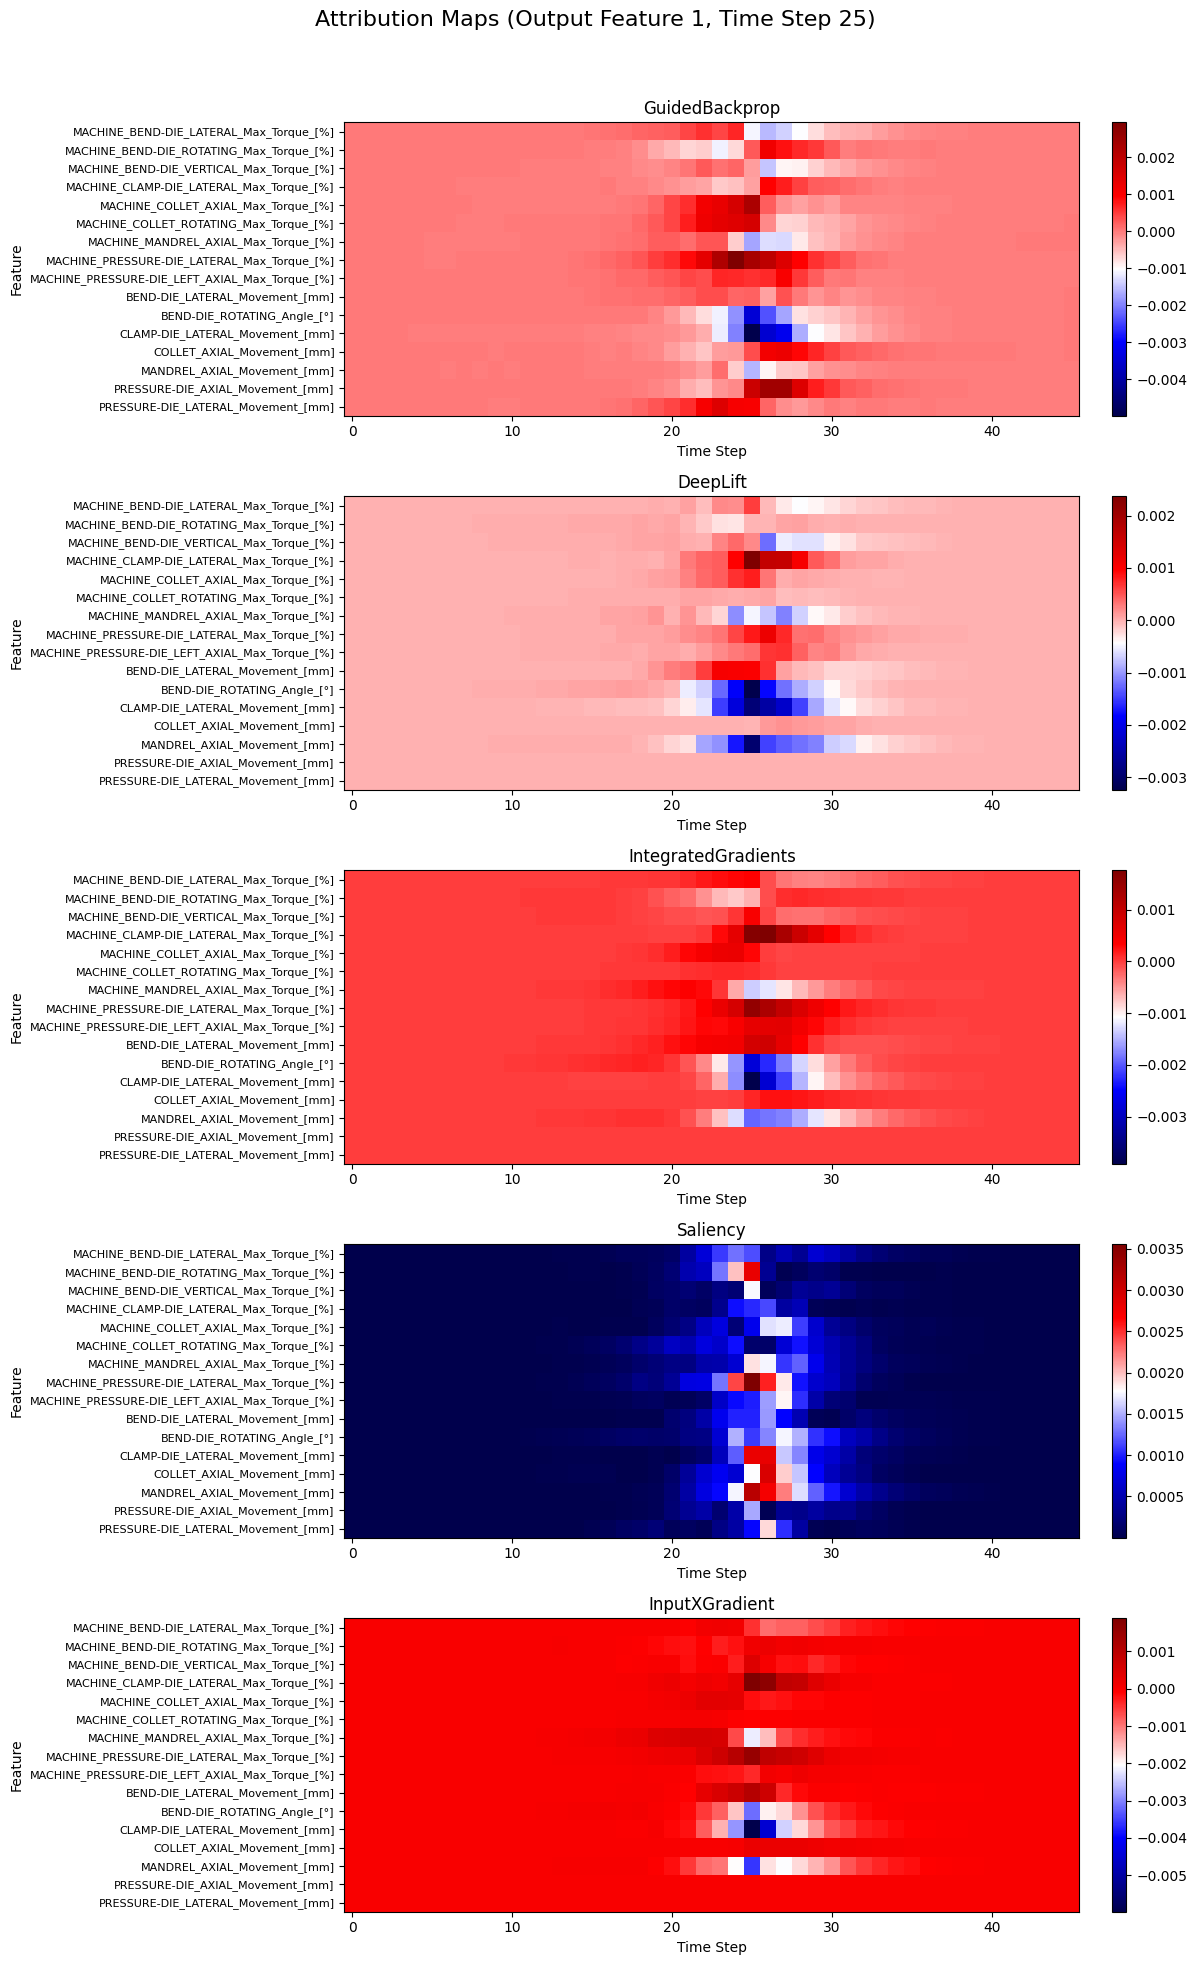

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import GuidedBackprop, DeepLift, IntegratedGradients, Saliency, InputXGradient

# --------------------------
# Pick a sample input to explain
# --------------------------
feature_names = list(sensors_df.columns)[1:]
sample_input = x_tensor[0:1]  # (1,46,16)
target_time_step = 25
target_output_feature = 1

# --------------------------
# Wrap model for scalar output
# --------------------------
class WrappedModel(nn.Module):
    def __init__(self, base_model, time_step, output_feature):
        super().__init__()
        self.base_model = base_model
        self.time_step = time_step
        self.output_feature = output_feature

    def forward(self, x):
        out = self.base_model(x)
        return out[:, self.time_step, self.output_feature]

wrapped_model = WrappedModel(model, target_time_step, target_output_feature)

# --------------------------
# Define attribution methods
# --------------------------
methods = {
    "GuidedBackprop": GuidedBackprop,
    "DeepLift": DeepLift,
    "IntegratedGradients": IntegratedGradients,
    "Saliency": Saliency,
    "InputXGradient": InputXGradient
}

n_methods = len(methods)
fig, axes = plt.subplots(n_methods, 1, figsize=(12, 4 * n_methods))  # vertical stack
axes = axes.flatten() if n_methods > 1 else [axes]

for i, (name, method_cls) in enumerate(methods.items()):
    method = method_cls(wrapped_model)
    attr = method.attribute(sample_input)
    attr_np = attr.detach().numpy().reshape(46, 16)

    im = axes[i].imshow(attr_np.T, cmap='seismic', aspect='auto')
    axes[i].set_title(name)
    axes[i].set_xlabel("Time Step")
    axes[i].set_ylabel("Feature")
    axes[i].set_yticks(np.arange(len(feature_names)))
    axes[i].set_yticklabels(feature_names, fontsize=8)
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle(f"Attribution Maps (Output Feature {target_output_feature}, Time Step {target_time_step})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [12]:
%%capture
!pip uninstall timesynth --yes
!pip install git+https://github.com/TimeSynth/TimeSynth.git

In [13]:
import torch as th
import matplotlib.pyplot as plt
from tint.attr import DynaMask
from tint.models import MLP

# --------------------------tint library
# Dummy data
# --------------------------
inputs = th.from_numpy(X).float() 
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, 
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden_size)
        out = self.fc(out)    # shape: (batch, seq_len, output_size)
        # if you want only the last time step prediction:
        # out = out[:, -1, :]
        return out

rnn = SimpleRNN(input_size=X.shape[-1], hidden_size=15, num_layers=1, output_size=1)

# --------------------------
# Compute attributions
# --------------------------
explainer = DynaMask(model)
attr = explainer.attribute(inputs)  # shape: (batch, time, features, ? depends on DynaMask)

# Convert to numpy for visualization
attr_np = attr.detach().numpy()

# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(inputs.size(2))]

# Plot heatmap for each sample

plt.figure(figsize=(8,4))
plt.imshow(attr_np[0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"DynaMask Attributions for Sample {i}")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()


ModuleNotFoundError: No module named 'tint'

In [ ]:
import torch as th
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tint.attr import SequentialIntegratedGradients

# --------------------------
# Assume X and Y are your data
# X shape: [num_samples, time_steps, features]
# Y shape: [num_samples, time_steps, all_features]
# --------------------------

# Example: Use first 5 samples
inputs = th.tensor(X[:10,:,:]).float()
X_tensor = th.tensor(X[:10,:,:]).float()
# Select only the outputs you want to predict, one value per output per sample
y_tensor = th.tensor(Y[:10, :, 1]).float()  # last timestep, outputs 1 and 2
batch_size, time_steps, features = X_tensor.shape
num_outputs = y_tensor.shape[1]

# --------------------------
# Define LSTM Regressor
# --------------------------
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)  # map last hidden to multiple outputs

    def forward(self, x):
        out, _ = self.lstm(x)         # [batch, time_steps, hidden_size]
        out = out[:, -1, :]           # take last timestep
        out = self.fc(out)            # [batch, num_outputs]
        return out

hidden_size = 32
mlp = LSTMRegressor(features, hidden_size, num_outputs)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

# --------------------------
# Train LSTM
# --------------------------
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mlp(X_tensor)          # [batch, num_outputs]
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.3217
Epoch [20/100], Loss: 0.2047
Epoch [30/100], Loss: 0.0897
Epoch [40/100], Loss: 0.0313
Epoch [50/100], Loss: 0.0096
Epoch [60/100], Loss: 0.0034
Epoch [70/100], Loss: 0.0010
Epoch [80/100], Loss: 0.0006
Epoch [90/100], Loss: 0.0005
Epoch [100/100], Loss: 0.0005


In [ ]:
# --------------------------
# Compute Attributions
# --------------------------
explainer = SequentialIntegratedGradients(model)

# Compute attributions for each output separately
attrs = []
for target_idx in range(num_outputs):
    attr = explainer.attribute(inputs, target=target_idx)
    attrs.append(attr.detach().numpy())  # shape: [batch, time_steps, features]

AssertionError: Target not provided when necessary, cannot take gradient with respect to multiple outputs.

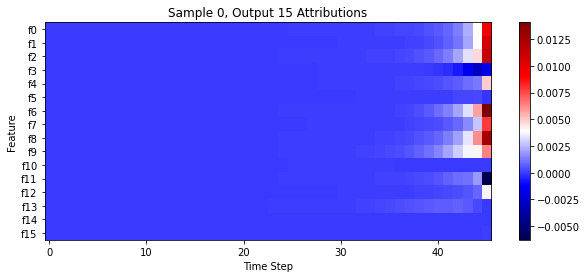

In [ ]:
# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[15][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

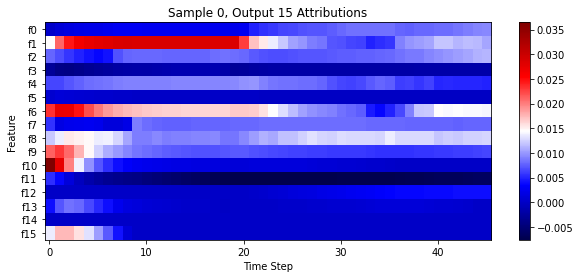

In [ ]:
import torch as th
from tint.attr import TemporalIntegratedGradients
from tint.models import MLP

explainer = TemporalIntegratedGradients(mlp)
# --------------------------
# Visualization
# --------------------------
attrs = []
for target_idx in range(num_outputs):
    attr = explainer.attribute(inputs, target=target_idx)
    attrs.append(attr.detach().numpy())  # shape: [batch, time_steps, features]


# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[15][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

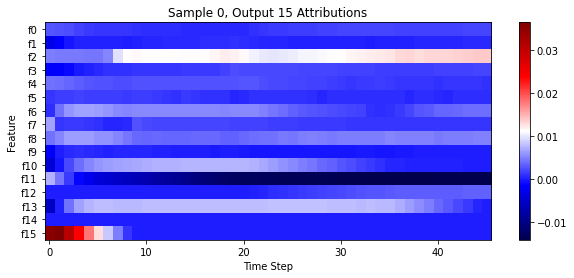

In [ ]:
# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[45][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

In [ ]:
import torch as th
from tint.attr import TimeForwardTunnel
from captum.attr import Saliency
from tint.models import MLP

explainer = TimeForwardTunnel(Saliency(mlp))
# --------------------------
# Visualization
# --------------------------
attrs = []
for target_idx in range(num_outputs):
    attr = explainer.attribute(inputs, target=target_idx)
    attrs.append(attr.detach().numpy())  # shape: [batch, time_steps, features]


Input Tensor 0 did not already require gradients, required_grads has been set automatically.


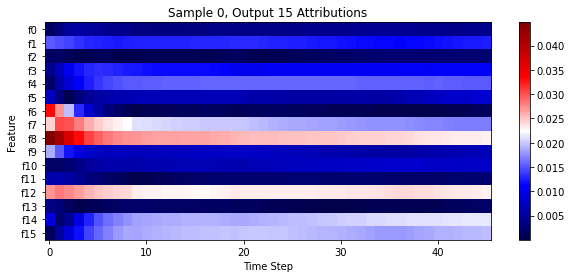

In [ ]:
# --------------------------
# Visualization
# --------------------------
feature_names = [f"f{i}" for i in range(features)]

plt.figure(figsize=(10,4))
plt.imshow(attrs[0][0].T, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"Sample {0}, Output {15} Attributions")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=range(len(feature_names)), labels=feature_names)
plt.show()

WinIT attributions shape: (1, 16, 46, 3)


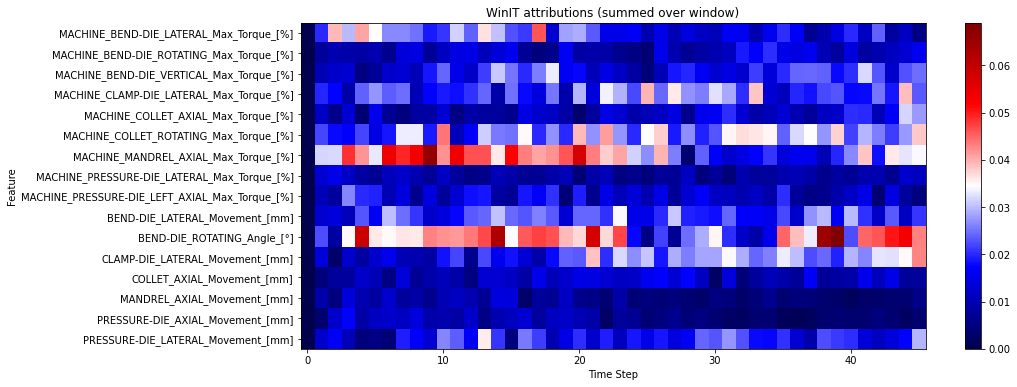

In [ ]:
from __future__ import annotations

import logging
from pathlib import Path
from time import time

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --------------------------
# Your LSTM model
# --------------------------
class LSTMTimeSeries(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out, _ = self.lstm(x)  # out: (batch, seq_len, hidden_dim)
        out = self.fc(out)      # (batch, seq_len, output_dim)
        return out

# --------------------------
# Wrapper for WinIT
# --------------------------
class LSTMWrapper(nn.Module):
    """
    Wrap the LSTM model to provide .predict() for WinITExplainer.
    Handles (batch, features, time_steps) -> (batch, time_steps, features)
    """
    def __init__(self, model: nn.Module, device=torch.device("cpu")):
        super().__init__()
        self.model = model.to(device)
        self.device = device
        self.num_states = model.fc.out_features

    def forward(self, x):
        return self.predict(x)

    def predict(self, x: torch.Tensor, return_all=False):
        # Swap axes: (batch, features, time_steps) -> (batch, time_steps, features)
        x = x.permute(0, 2, 1).to(self.device)
        with torch.no_grad():
            out = self.model(x)  # (batch, time_steps, output_dim)
        if return_all:
            return out
        return out[:, -1, :]  # last time step

# --------------------------
# Prepare data loader
# --------------------------
batch_size = 16
dataset = TensorDataset(x_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --------------------------
# Initialize WinITExplainer
# --------------------------
from winit.explainer.winitexplainers import WinITExplainer

device = torch.device("cpu")
num_features = x_tensor.shape[2]

lstm_model = LSTMTimeSeries(input_dim=num_features, hidden_dim=32, output_dim=y_tensor.shape[2])
wrapped_model = LSTMWrapper(lstm_model, device=device)

explainer = WinITExplainer(
    device=device,
    num_features=num_features,
    data_name="mydata",
    path=Path("./winit_generators"),
    train_loader=train_loader,
    window_size=3,
    num_samples=3,
    conditional=False,
    joint=False,
    metric="pd",
    random_state=42
)
explainer.base_model = wrapped_model

# --------------------------
# Pick a sample input and compute attributions
# --------------------------
sample_input = x_tensor[1:2]  # shape: (1, time_steps, features)
# WinIT expects shape: (batch, features, time_steps)
sample_input = sample_input.permute(0, 2, 1)

attributions = explainer.attribute(sample_input)
print("WinIT attributions shape:", attributions.shape)  # (1, features, time_steps, window_size)

# --------------------------
# Visualize attributions
# --------------------------
import matplotlib.pyplot as plt

# Sum over window dimension for visualization
attr_sum = attributions[0].sum(axis=-1)  # (features, time_steps)
plt.figure(figsize=(14,6))
plt.imshow(attr_sum, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title("WinIT attributions (summed over window)")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()


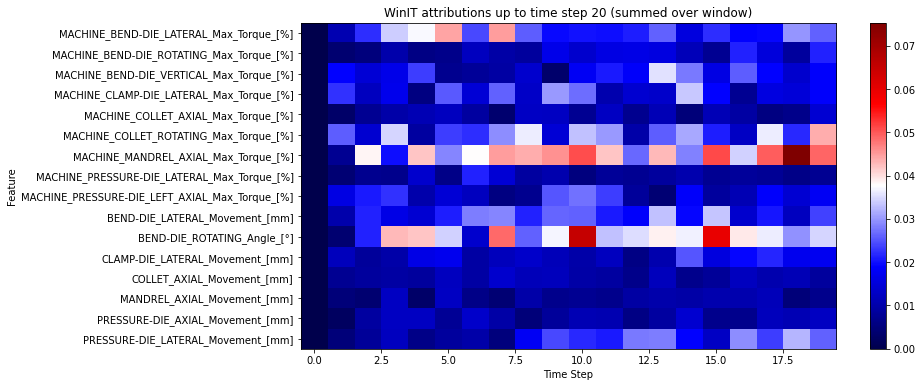

In [ ]:
# Suppose your sample_input is already prepared: (batch, features, time_steps)
attributions = explainer.attribute(sample_input)  # shape: (1, features, time_steps, window_size)

# Specify the timestamp (time step index) you want to go up to
t_max = 20  # example: get attributions from t=0 to t=10

# Slice the attributions along the time_steps axis
attr_up_to_t = attributions[0, :, :t_max, :15]  # shape: (features, t_max, window_size)

# For visualization, you might sum over the window dimension
attr_sum_up_to_t = attr_up_to_t.sum(axis=-1)  # shape: (features, t_max)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.imshow(attr_sum_up_to_t, cmap='seismic', aspect='auto')
plt.colorbar()
plt.title(f"WinIT attributions up to time step {t_max} (summed over window)")
plt.xlabel("Time Step")
plt.ylabel("Feature")
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.show()
